$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 3.3

## 理论

在实际研究中，无法在开展实验前预先获知尺度参数的取值。因此，探究该参数是否会对最优试验设计产生影响具有重要意义。图 3.3 上方子图绘制了积分均方误差（IMSE）与最小最大均方误差（MMSE）的数值曲线。可以看出两类误差数值随 $\theta$ 变化显著。当 $\theta$ 取值极小或极大时，各类试验设计的表现趋于一致。该现象可以合理解释：$\theta$ 取值较小时，响应曲面起伏剧烈，全部 10 组试验设计均难以精准拟合该响应曲面；与之类似，$\theta$ 取值较大时，响应曲面平缓光滑，所有试验设计均可较好地完成曲面拟合。只有当 $\theta$ 处于中间区间时，不同试验设计的性能才会出现明显差异。可定义相对效率用以区分不同试验设计的优劣，对应公式如下：

相对积分均方效率：

$$
RE_I(D_i; \boldsymbol{\theta})=
\frac{\min_i \text{IMSE}(D_i; \boldsymbol{\theta})}
{\text{IMSE}(D_i; \boldsymbol{\theta})}
$$

相对最小最大均方效率：

$$
RE_M(D_i; \boldsymbol{\theta})=
\frac{\min_i \text{MMSE}(D_i; \boldsymbol{\theta})}
{\text{MMSE}(D_i; \boldsymbol{\theta})}
$$

其中 $i=1,2,3,4$。

四种设计方案在积分均方误差（IMSE）与最小均方误差（MMSE）指标下的相对效率绘制于图 3.3 下方子图中。可以看出，最优设计方案会随着参数 $\theta$ 取值的变化而改变。例如，当 $\theta < 0.3$ 时，切比雪夫设计在积分均方误差指标下表现很差，但当 $\theta > 0.3$ 时该设计性能最优。这一结果对我们的最优设计方案而言是不利的。不过仍存在可行思路：等间隔设计与最小均方误差最优设计即便无法在任意 $\theta$ 取值下达到最优，但其在全部 $\theta$ 取值范围内的表现都较为稳定。因此，我们需要求解对参数 $\theta$ 具备鲁棒性的设计方案，该优化问题可表示为：

$$
\max_{D}\min_{\boldsymbol{\theta}\in\Theta}\frac{\text{IMSE}(D^*(\boldsymbol{\theta}); \boldsymbol{\theta})}{\text{IMSE}(D; \boldsymbol{\theta})}
$$

其中

$$
D^*(\boldsymbol{\theta}) = \argmin_{\boldsymbol{\theta}\in\Theta}\text{IMSE}(D; \boldsymbol{\theta})
$$

且 $\Theta \subset[0, +\infty)^p$。鲁棒最小均方误差最优设计可按照相同方式定义。

由图 3.3 可见，当 $\theta$ 趋近于 0（即相关性趋近于 0）时，所有设计方案的表现均较差，该情形对应变量近似相互独立。在此条件下，矩阵 $\boldsymbol{R}$ 趋近于单位矩阵 $\boldsymbol{I}$，因此无需对矩阵 $\boldsymbol{R}$ 求逆即可计算集成均方误差（IMSE）准则与最小均方误差（MMSE）准则，能够大幅降低计算量。此外，在该极限条件下求得的各类设计方案，在相关性较强的场景中同样具备不错的效果。这类设计被称作填充设计，不仅构造难度更低，还能够抵御相关结构设定错误带来的影响，具备稳健性。因此我们将填充设计作为计算机试验的初始设计。

## 实践

创建画布宽 20 英寸、高 10 英寸，将画布分为 2x2。令 n=10，theta=0.1。依据 $[0,1]$ 间含端点的等距公式

$$
\left\{\frac{i-1}{n-1}\right\}_{i=1}^{n}
$$

创建 n 个点作为第一种设计观测点的横坐标，令其为 D1。依据 $[0,1]$ 间的切比雪夫设计公式

$$
D_2=\left\{0.5+0.5\cos\left(\frac{\pi(i-0.5)}{n}\right)\right\}_{i=1}^n
$$

创建 n 个点作为第二种观测点的横坐标，令其为 D2。依据 $[0,1]$ 间不含端点的等距公式

$$
\left\{\frac{i-0.5}{n-1}\right\}_{i=1}^{n}
$$

创建 n 个点作为优化初始值，令其为 D0。导入 gpcrit 包。调用 optim() 函数，其中初始点集为 D0，待优化的函数为 IMSE，下界为 0，上界为 1，算法为“L-BFGS-B”，优化后的列表取 par 列正是最终选定的第三种观测点集横坐标，令其为 D3。调用 optim() 函数，其中初始点集为 D0，待优化的函数为 MMSE，下界为 0，上界为 1，算法为“L-BFGS-B”，优化后的列表取 par 列正是最终选定的第四种观测点集横坐标，令其为 D4。

在 $[0.01,0.4]$ 间等距取 301 个点作为参数 $\theta$ 的取值，令其为 ev。创建 301x4 的矩阵 IR 与 MR，分别用于存储积分均方误差（IMSE）与最小均方误差（MMSE）的计算结果。循环遍历 ev 中的每个参数 $\theta$，调用 imse() 函数计算四种设计方案在该参数下的积分均方误差（IMSE），将计算结果存入 IR 矩阵；调用 mmse() 函数计算四种设计方案在该参数下的最小均方误差（MMSE），将计算结果存入 MR 矩阵。

绘制积分均方误差的 4 种试验设计方案的数值曲线，其中类型为 l，x 轴的标注为 expression(theta)，y 轴的标注为 IMSE，大小为 2，线宽为 4，标题为“积分均方误差”，大小为 4，x 轴与 y 轴的刻度大小均为 2。添加图例，其中位置在 (.05,1)，图例内容为“等距设计”、“切比雪夫设计”、“积分均方误差最优设计”、“最小均方误差最优设计”，线型分别为 1:4，颜色分别为 1:4，线宽均为 4，边框类型为无，大小为 2。绘制最小均方误差的 4 种试验设计方案的数值曲线，其中类型为 l，x 轴的标注为 $\theta$，y 轴的标注为 MMSE，线宽为 4，标题为“最小均方误差”，大小为 4，x 轴与 y 轴的标注大小均为 2，x 轴与 y 轴的刻度大小均为 2。

依据公式

$$
RE_I(D_i; \boldsymbol{\theta})=\frac{\min_i IMSE(D_i; \boldsymbol{\theta})}{IMSE(D_i; \boldsymbol{\theta})}
$$

计算相对积分均方效率，令其为 IRR。绘制积分均方误差的 4 种试验设计方案的相对积分均方效率曲线，其中类型为 l，x 轴的标注为 expression(theta)，y 轴的标注为 RE，大小为 2，线宽为 4，标题为“基于积分均方误差的相对效率”，大小为 4，x 轴与 y 轴的刻度大小均为 2。依据公式

$$
RE_M(D_i; \boldsymbol{\theta})=\frac{\min_i MMSE(D_i; \boldsymbol{\theta})}{MMSE(D_i; \boldsymbol{\theta})}
$$

计算相对最小最大均方效率，令其为 MRR。绘制最小均方误差的 4 种试验设计方案的相对最小最大均方效率曲线，其中类型为 l，x 轴的标注为 expression(theta)，y 轴的标注为 RE，大小为 2，线宽为 4，标题为“基于最小均方误差的相对效率”，大小为 4，x 轴与 y 轴的刻度大小均为 2。将画布还原回 1x1。

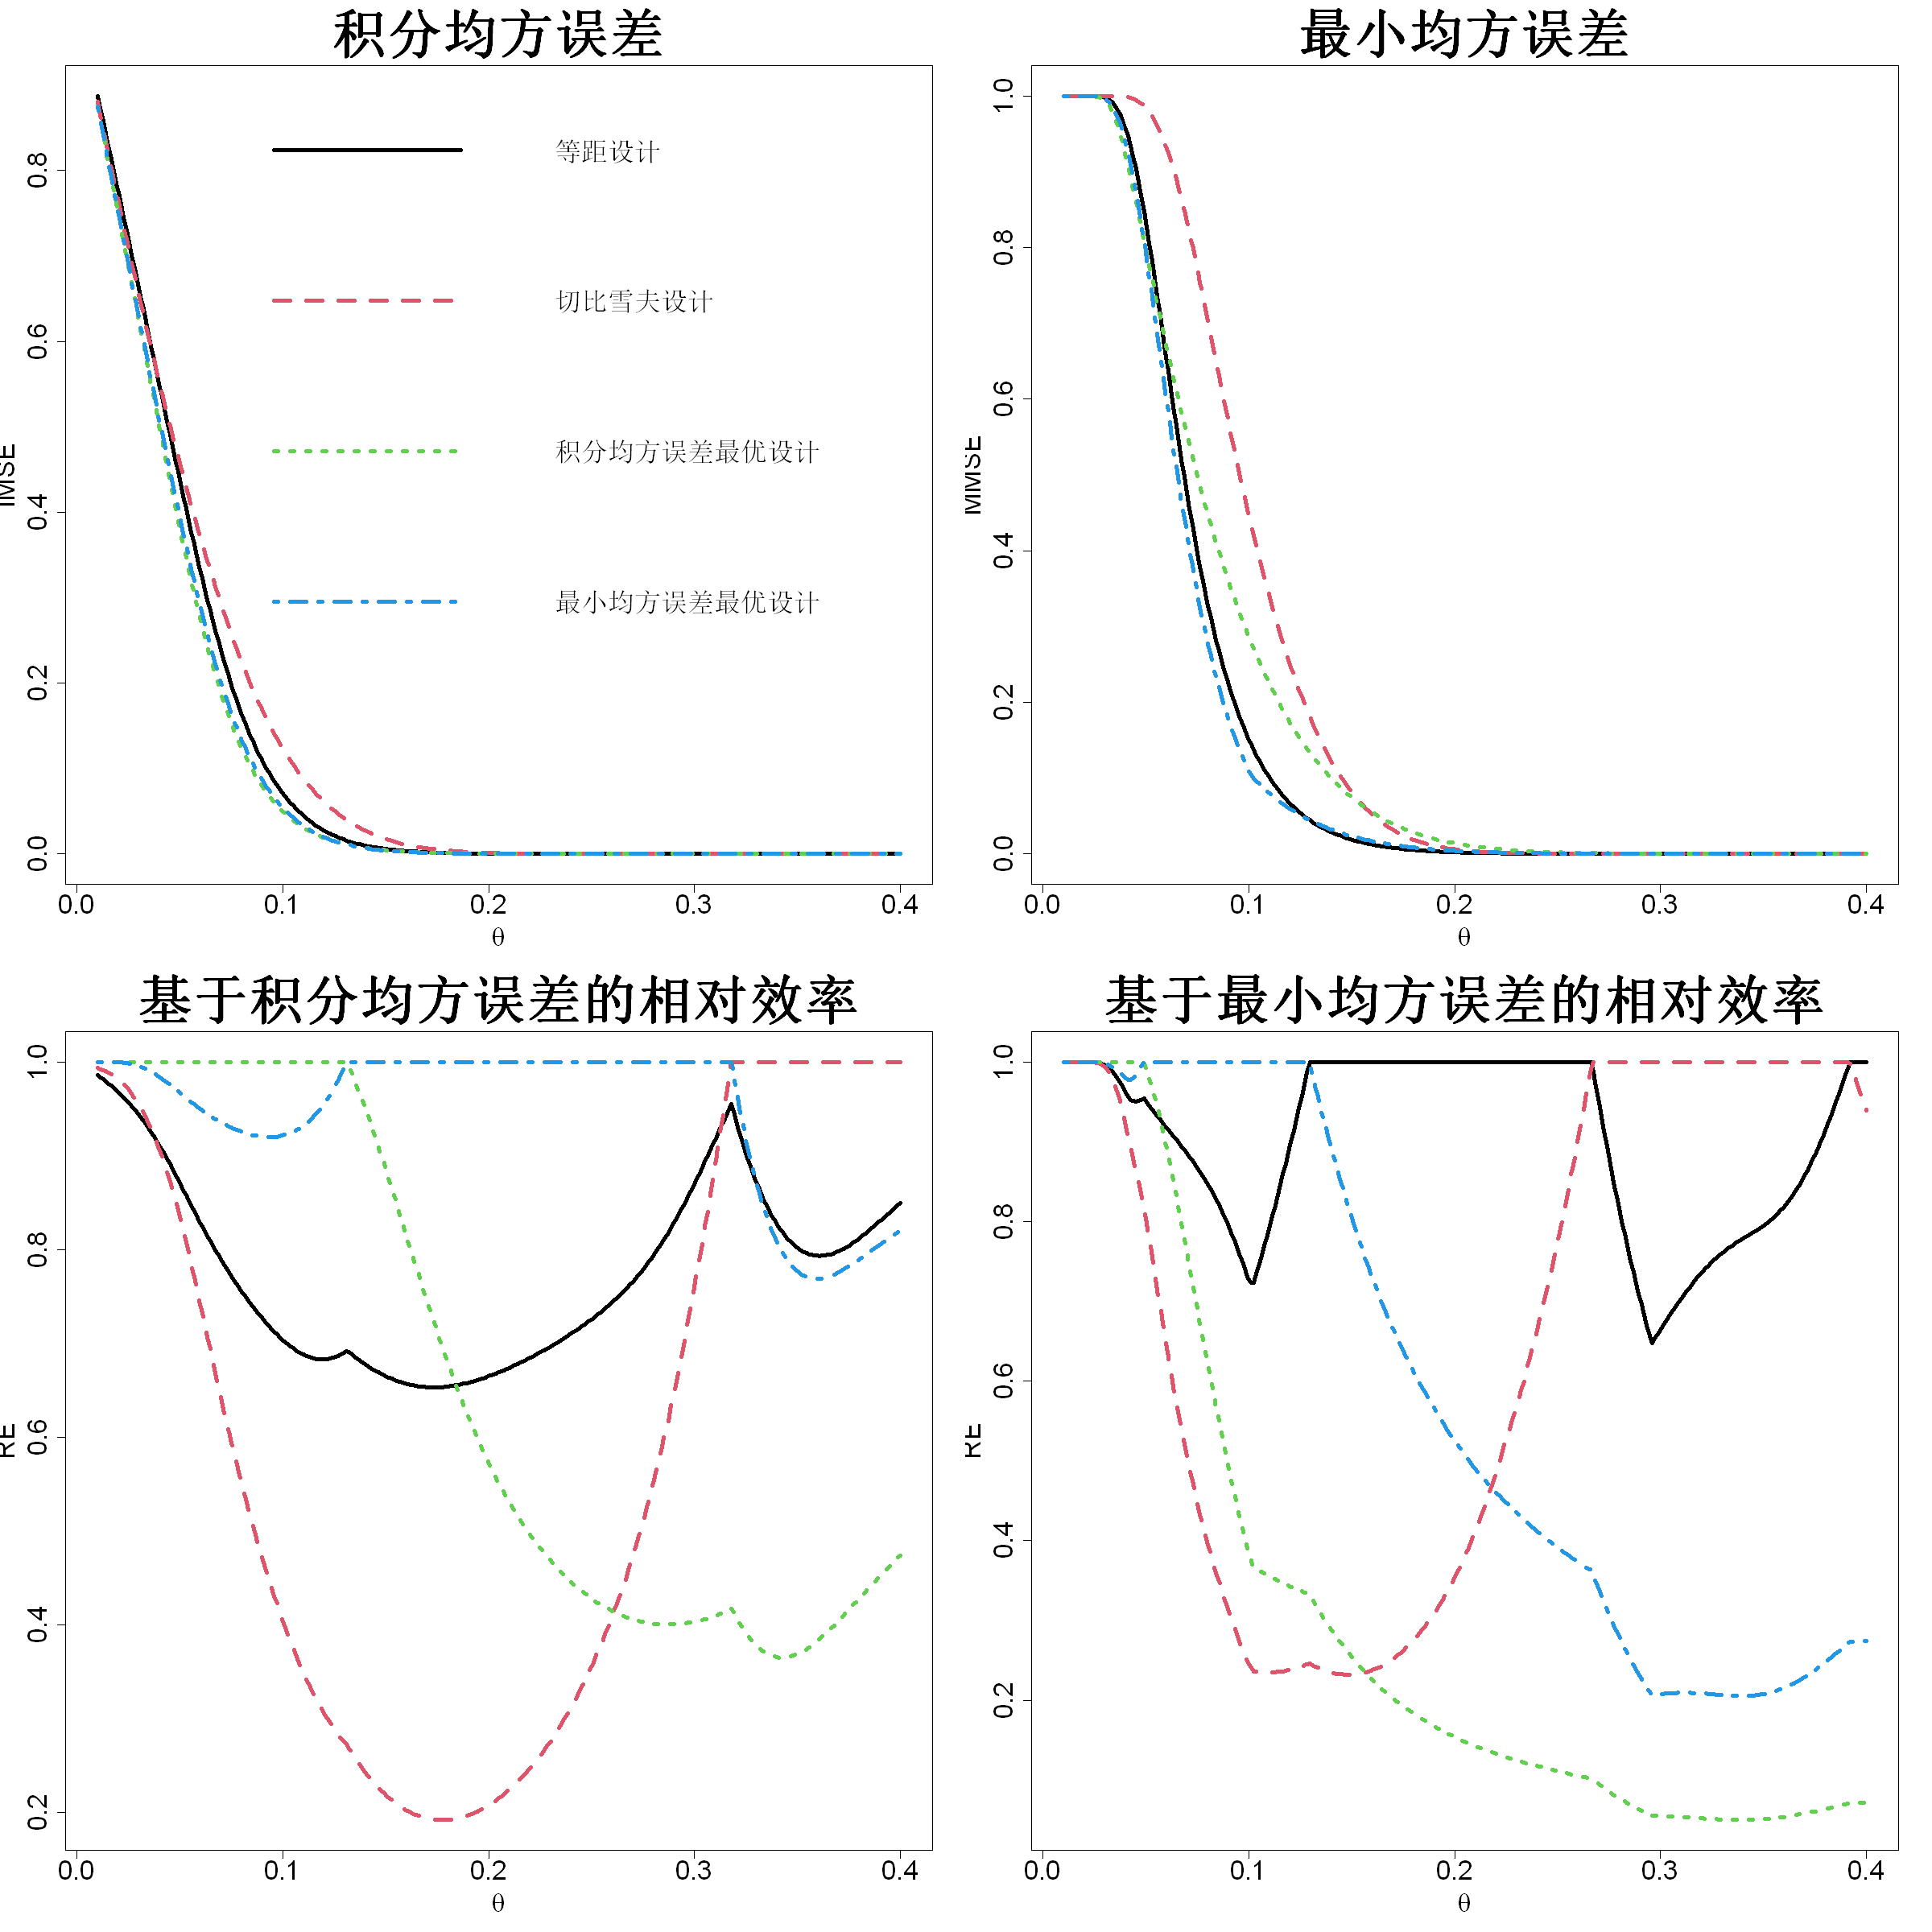

In [2]:
options(repr.plot.width=20,repr.plot.height=20)
par(mfrow=c(2,2))
n=10;theta=.1
D1=((1:n)-1)/(n-1)
D2=.5+.5*cos((pi*(1:n)-.5)/n)
D0=((1:n)-.5)/n
library(gpcrit)
D3=optim(D0,function(D) imse(D,theta),lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")$par
D4=optim(D0,function(D) mmse(D,theta),lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")$par

ev=seq(.01,.4,length=301)
IR=MR=matrix(0,nrow=301,ncol=4)
for(i in 1:301){
    theta=ev[i]
    IR[i,]=c(imse(D1,theta),imse(D2,theta),imse(D3,theta),imse(D4,theta))
    MR[i,]=c(mmse(D1,theta),mmse(D2,theta),mmse(D3,theta),mmse(D4,theta))
}

matplot(ev,IR,type="l",xlab=expression(theta),ylab="IMSE",cex.lab=2,lwd=4,main="积分均方误差",cex.main=4,cex.axis=2)
legend(.05,1,legend=c("等距设计","切比雪夫设计","积分均方误差最优设计","最小均方误差最优设计"),lty=1:4,col=1:4,lwd=4,bty="n",cex=2)
matplot(ev,MR,type="l",xlab=expression(theta),ylab="MMSE",cex.lab=2,lwd=4,main="最小均方误差",cex.main=4,cex.axis=2)

IRR=apply(IR,1,min)/IR
matplot(ev,IRR,type="l",xlab=expression(theta),ylab="RE",cex.lab=2,lwd=4,main="基于积分均方误差的相对效率",cex.main=4,cex.axis=2)
MRR=apply(MR,1,min)/MR
matplot(ev,MRR,type="l",xlab=expression(theta),ylab="RE",cex.lab=2,lwd=4,main="基于最小均方误差的相对效率",cex.main=4,cex.axis=2)
par(mfrow=c(1,1))

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$